# Perceptron — An Illustrated Tour

> The original learning algorithm (Rosenblatt 1958). One linear neuron, an online error-driven update, and a guarantee: if the data are linearly separable, the perceptron finds a separator in finitely many mistakes.

---

**What we cover:**
- The mistake-driven update $w \leftarrow w + y x$
- Snapshots of the weight vector and decision boundary as it learns
- Mistake-bound theorem (Novikoff)
- Failure on non-separable data
- Connection to modern neural nets

## The picture — a hyperplane updated only on mistakes

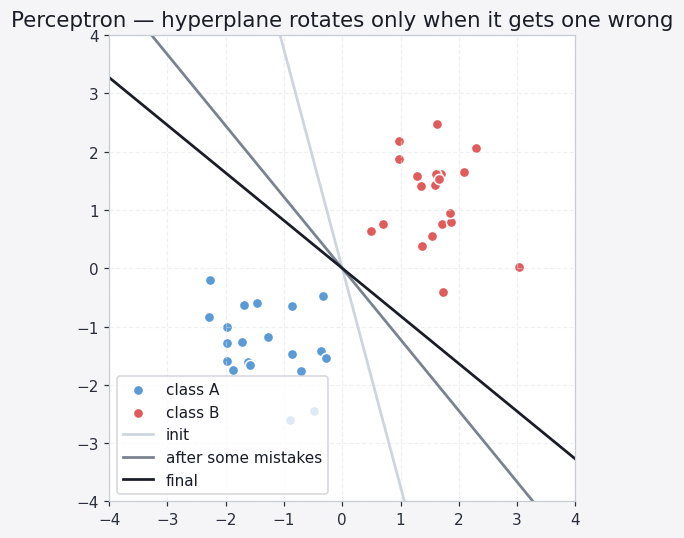

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(1)
A = rng.randn(20, 2)*0.7 + np.array([-1.5, -1])
B = rng.randn(20, 2)*0.7 + np.array([ 1.5,  1])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(A[:,0], A[:,1], s=45, color=P[0], edgecolor='white', label='class A')
ax.scatter(B[:,0], B[:,1], s=45, color=P[1], edgecolor='white', label='class B')
xx = np.linspace(-4, 4, 100)
for w, c, lab in [((1.5,0.4), '#cfd5dd', 'init'),
                  ((1.1,0.9), '#7a8290', 'after some mistakes'),
                  ((0.9,1.1), '#1a1d27', 'final')]:
    a, b = w; ax.plot(xx, -a*xx/b, color=c, lw=1.8, label=lab)
ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect('equal'); ax.grid(True)
ax.set_title('Perceptron — hyperplane rotates only when it gets one wrong')
ax.legend(); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

rng = np.random.default_rng(0)
n = 80
Xpos = rng.normal(loc=( 1.5,  1.0), scale=0.6, size=(n, 2))
Xneg = rng.normal(loc=(-1.5, -1.0), scale=0.6, size=(n, 2))
X = np.vstack([Xpos, Xneg])
y = np.r_[np.ones(n), -np.ones(n)]
X_aug = np.column_stack([np.ones(len(X)), X])    # bias trick
print('Linearly separable data ready.')

Linearly separable data ready.


---
## The Update Rule

Initialise $w \in \mathbb{R}^{d+1}$ to zero (the leading entry is the bias).
Cycle through the data; on each $(x_i, y_i)$ with $y_i \in \{-1, +1\}$:

$$\hat y_i = \operatorname{sign}(w \cdot x_i),\qquad \text{if } \hat y_i \neq y_i: \quad w \leftarrow w + y_i\, x_i.$$

Each mistake nudges $w$ toward the correct half-space.

In [3]:
def train_perceptron(X, y, snaps_at=(1, 3, 5, 20)):
    w = np.zeros(X.shape[1]); mistakes = 0; snaps = {}
    history = []
    converged = False
    for epoch in range(50):
        m_epoch = 0
        for xi, yi in zip(X, y):
            if yi * (w @ xi) <= 0:
                w = w + yi * xi
                mistakes += 1; m_epoch += 1
                if mistakes in snaps_at: snaps[mistakes] = w.copy()
        history.append(m_epoch)
        if m_epoch == 0: converged = True; break
    return w, mistakes, snaps, history, converged

w_final, total_mistakes, snaps, mistakes_per_epoch, converged = train_perceptron(X_aug, y)
print(f'Total mistakes: {total_mistakes}, converged: {converged}, epochs: {len(mistakes_per_epoch)}')

Total mistakes: 2, converged: True, epochs: 2


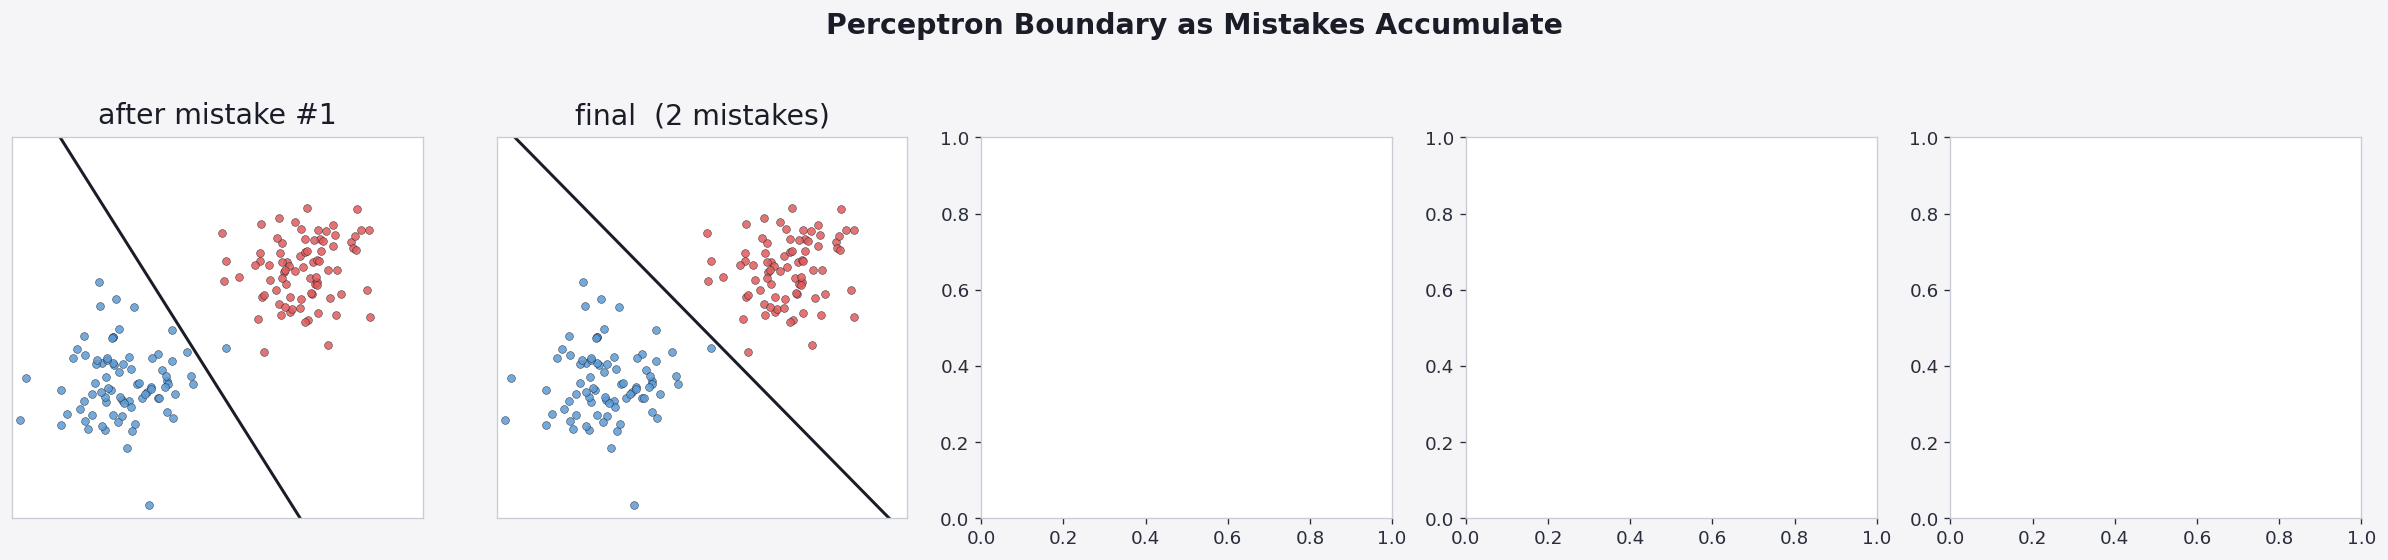

In [4]:
def plot_boundary(ax, w, title):
    ax.scatter(Xpos[:,0], Xpos[:,1], c=C1, s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85, label='+1')
    ax.scatter(Xneg[:,0], Xneg[:,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85, label='−1')
    if abs(w[2]) > 1e-9:
        xs = np.linspace(-3.5, 3.5, 100)
        ys = -(w[0] + w[1]*xs) / w[2]
        ax.plot(xs, ys, color='#1a1d27', lw=1.8)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, pad=8)

fig, axes = plt.subplots(1, 5, figsize=(20, 4.4))
ordered = sorted(snaps.keys()) + [None]
for ax, key in zip(axes, ordered):
    if key is None: plot_boundary(ax, w_final, f'final  ({total_mistakes} mistakes)')
    else:           plot_boundary(ax, snaps[key], f'after mistake #{key}')
fig.suptitle('Perceptron Boundary as Mistakes Accumulate', fontsize=17, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

---
## Mistake-Bound Theorem (Novikoff)

Suppose all $\|x_i\| \le R$ and there exists a unit-norm $u$ with $y_i\,(u \cdot x_i) \ge \gamma > 0$ for all $i$. Then the perceptron makes at most

$$M \le \Bigl(\frac{R}{\gamma}\Bigr)^2$$

mistakes before converging. The bound is **independent of the dimension** — only the geometric **margin** $\gamma$ and the data radius $R$ matter.

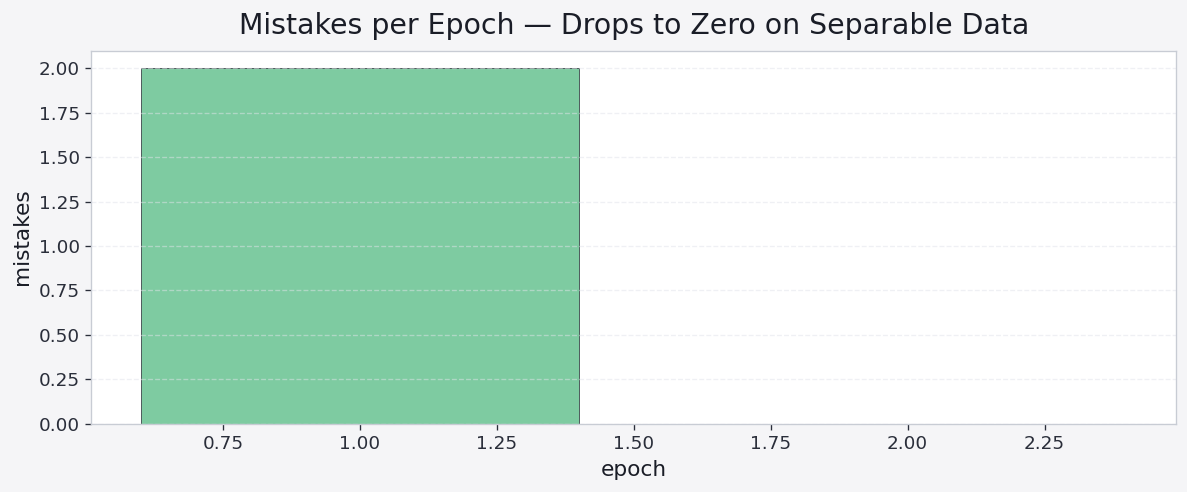

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(range(1, len(mistakes_per_epoch)+1), mistakes_per_epoch, color=CM, edgecolor='#1a1d27', lw=0.4)
ax.set_xlabel('epoch'); ax.set_ylabel('mistakes')
ax.set_title('Mistakes per Epoch — Drops to Zero on Separable Data', pad=10)
ax.grid(True, axis='y')
plt.tight_layout(); plt.show()

---
## Failure on Non-Separable Data

Add overlap between the classes; the perceptron never converges — it keeps thrashing because *any* separator must misclassify some points.

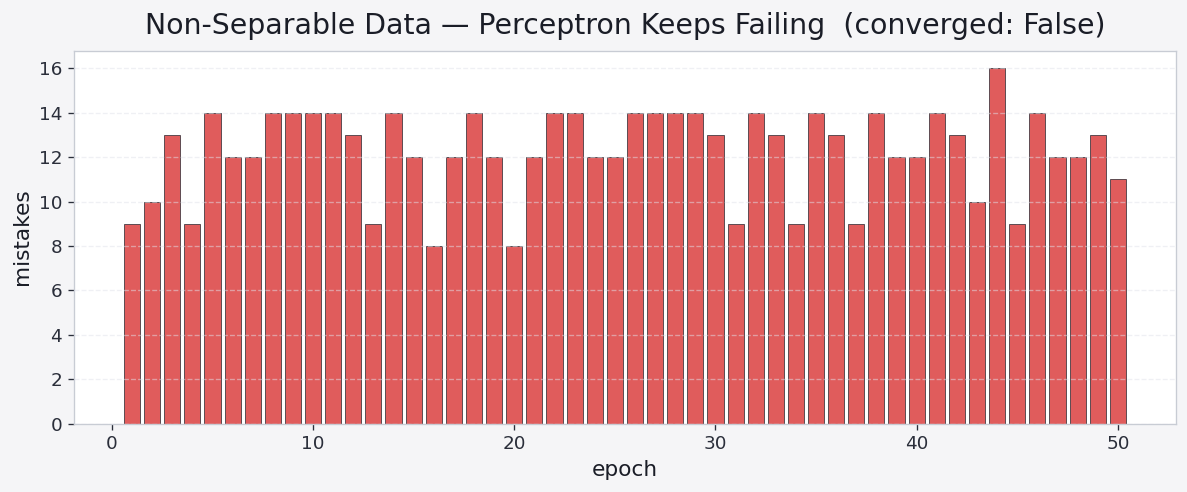

In [6]:
Xpos2 = rng.normal(loc=( 0.5,  0.5), scale=1.0, size=(n, 2))
Xneg2 = rng.normal(loc=(-0.5, -0.5), scale=1.0, size=(n, 2))
X2 = np.vstack([Xpos2, Xneg2])
y2 = np.r_[np.ones(n), -np.ones(n)]
X2_aug = np.column_stack([np.ones(len(X2)), X2])
_, total2, _, hist2, conv2 = train_perceptron(X2_aug, y2, snaps_at=())
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(range(1, len(hist2)+1), hist2, color=C1, edgecolor='#1a1d27', lw=0.4)
ax.set_xlabel('epoch'); ax.set_ylabel('mistakes')
ax.set_title(f'Non-Separable Data — Perceptron Keeps Failing  (converged: {conv2})', pad=10)
ax.grid(True, axis='y')
plt.tight_layout(); plt.show()

---
## Connection to Modern Networks

A perceptron is a **single linear neuron** with a step activation. Stack them, swap the step for a smooth activation (sigmoid, ReLU), and replace the discrete update with gradient descent on a differentiable loss — you've reinvented **multilayer neural networks**. The conceptual lineage from perceptron → logistic regression → deep networks is direct.

---
## ⚖️ When to use the Perceptron — and when not to

| Situation | Perceptron | Logistic | SVM | Modern NN |
|---|---|---|---|---|
| Strictly linearly separable data | ✅ provably converges | ✅ | ✅ best margin | overkill |
| Non-separable data | ❌ thrashes forever | ✅ | ✅ soft margin | ✅ |
| Need probability outputs | ❌ | ✅ | ❌ | ✅ |
| Education / historical context | ✅ original learning rule | ❌ | ❌ | ❌ |

> Today the perceptron is mostly a **stepping stone to deep learning** — read it as a simplified single neuron with a step activation.


---
## 🎯 Try this

1. **Margin matters.** Generate two datasets — one with a wide margin and one with a tiny margin between classes. Verify Novikoff's bound $M \le R^2/\gamma^2$ holds for both.
2. **Voted / averaged perceptron.** Keep the running mean of $w$ during training and predict with it. Robustness to non-separability improves dramatically.
3. **Dual form.** Express $w = \sum_i \alpha_i y_i x_i$ and update $\alpha_i$ instead of $w$. This is the perceptron viewed as the limit of a hard-margin SVM.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Update | $w \leftarrow w + y x$ on mistakes | Mistake-driven, online |
| Convergence | Finite if data linearly separable | Novikoff bound $M \le (R/\gamma)^2$ |
| Non-separable data | Never converges | Use a margin / soft-margin variant |
| Bias trick | Pad input with 1 | Bias becomes another weight |
| Strength | Simple, online, dimension-free bound | Foundation of every linear classifier |
| Weakness | Hard predictions only; no margin maximisation | Use logistic regression or SVM in practice |

**Bottom line:** The perceptron is the **'hello world' of learning algorithms** — a tiny rule with a beautiful theorem. Today's deep nets are direct descendants of this one-line update.